In [ ]:
import pandas as pd
df = pd.read_csv("/content/Crime_Data_from_2020_to_Present.csv")

In [ ]:
import time
start_time = time.time()

In [ ]:
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

/tmp/ipython-input-2630310296.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])
/tmp/ipython-input-2630310296.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])


In [ ]:
df['Vict Age'] = df['Vict Age'].fillna(df['Vict Age'].median())
categorical_cols = [
    'Vict Sex', 'Vict Descent', 'Weapon Desc',
    'Premis Desc', 'AREA NAME'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df = df[df['Vict Age'] > 0]
df = df[(df['LAT'] != 0) & (df['LON'] != 0)]
df['Occ Year'] = df['DATE OCC'].dt.year
df['Occ Month'] = df['DATE OCC'].dt.month
df['Occ Hour'] = df['TIME OCC'] // 100
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 721201 entries, 1 to 982636
Data columns (total 31 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DR_NO           721201 non-null  int64         
 1   Date Rptd       721201 non-null  datetime64[ns]
 2   DATE OCC        721201 non-null  datetime64[ns]
 3   TIME OCC        721201 non-null  int64         
 4   AREA            721201 non-null  int64         
 5   AREA NAME       721201 non-null  object        
 6   Rpt Dist No     721201 non-null  int64         
 7   Part 1-2        721201 non-null  int64         
 8   Crm Cd          721201 non-null  int64         
 9   Crm Cd Desc     721201 non-null  object        
 10  Mocodes         715630 non-null  object        
 11  Vict Age        721201 non-null  int64         
 12  Vict Sex        721201 non-null  object        
 13  Vict Descent    721201 non-null  object        
 14  Premis Cd       721200 non-null  float64 

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Occ Year,Occ Month,Occ Hour
1,200106753,2020-02-09,2020-02-08,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628,2020,2,18
2,200320258,2020-11-11,2020-11-04,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002,2020,11,17
3,200907217,2023-05-10,2020-03-10,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387,2020,3,20
4,220614831,2022-08-18,2020-08-17,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,...,NaN,NaN,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277,2020,8,12
5,231808869,2023-04-04,2020-12-01,2300,18,Southeast,1826,2,354,THEFT OF IDENTITY,...,NaN,NaN,NaN,9900 COMPTON AV,NaN,33.9467,-118.2463,2020,12,23


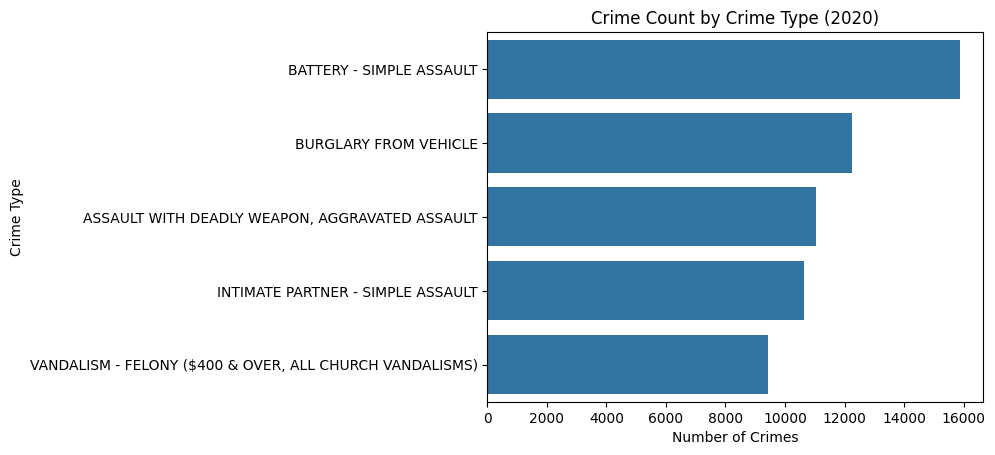

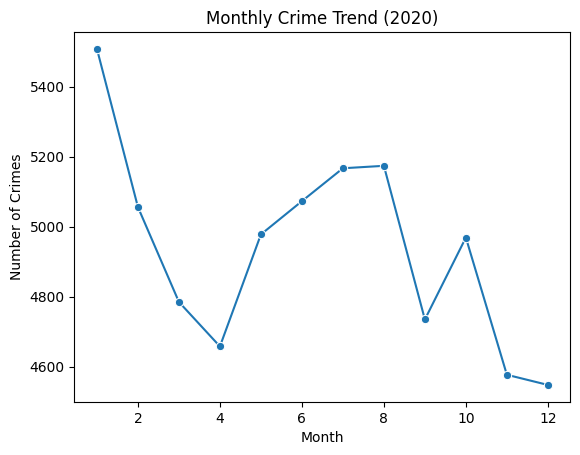

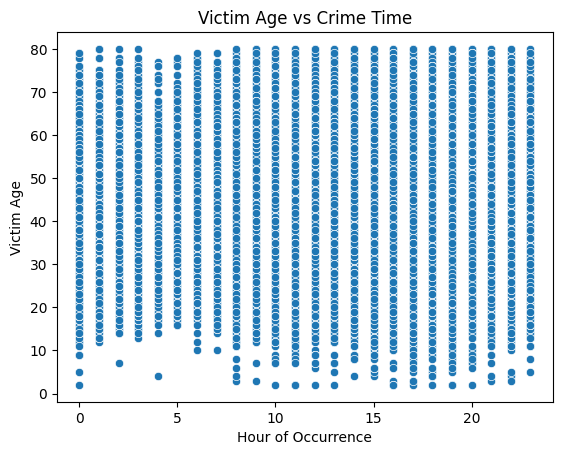

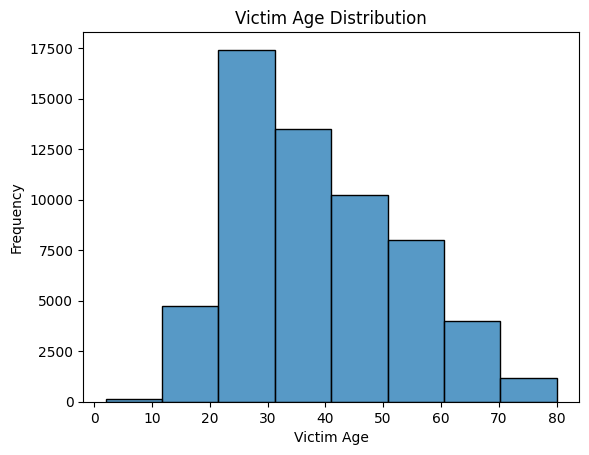

In [ ]:
#Task2
import matplotlib.pyplot as plt
import seaborn as sns
filtered_df = df[
    (df['Occ Year'] == 2020) &
    (df['Vict Age'] > 0) &
    (df['Vict Age'] <= 80)
]

top_crimes = filtered_df['Crm Cd Desc'].value_counts().head(5).index
filtered_df = filtered_df[filtered_df['Crm Cd Desc'].isin(top_crimes)]

#Chart 1: Bar Chart
crime_counts = filtered_df['Crm Cd Desc'].value_counts()
plt.figure()
sns.countplot(
    y='Crm Cd Desc',
    data=filtered_df,
    order=crime_counts.index
)
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")
plt.title("Crime Count by Crime Type (2020)")
plt.show()

#Chart 2: Line Chart
monthly_counts = filtered_df.groupby('Occ Month').size()
plt.figure()
sns.lineplot(
    x=monthly_counts.index,
    y=monthly_counts.values,
    marker='o'
)
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.title("Monthly Crime Trend (2020)")
plt.show()

#Chart 3: Scatter Plot
plt.figure()
sns.scatterplot(
    x='Occ Hour',
    y='Vict Age',
    data=filtered_df
)
plt.xlabel("Hour of Occurrence")
plt.ylabel("Victim Age")
plt.title("Victim Age vs Crime Time")
plt.show()

#Chart 4: Distribution Plot
plt.figure()
sns.histplot(filtered_df['Vict Age'], bins=8)
plt.xlabel("Victim Age")
plt.ylabel("Frequency")
plt.title("Victim Age Distribution")
plt.show()

/tmp/ipython-input-408243415.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


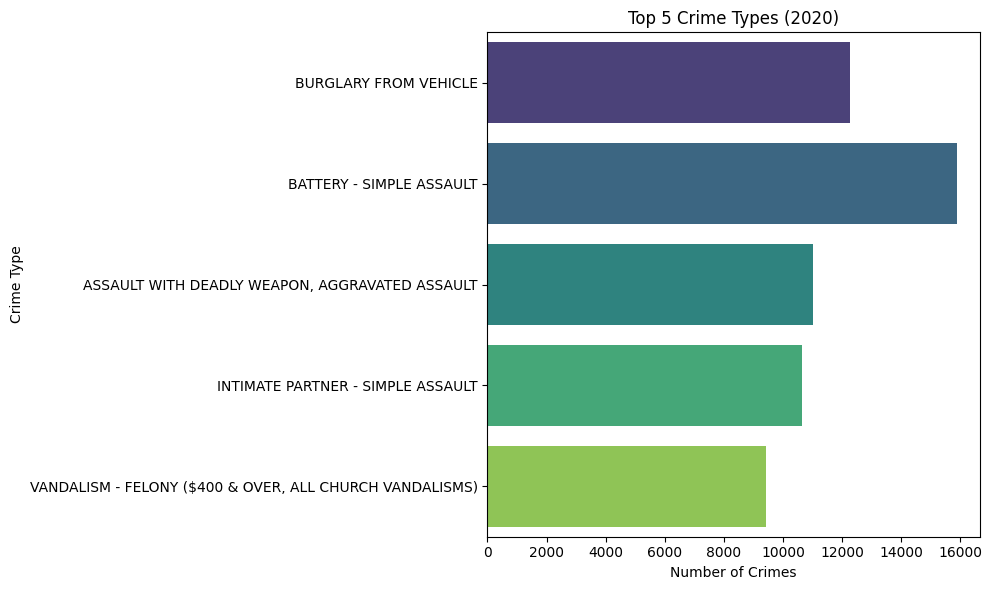

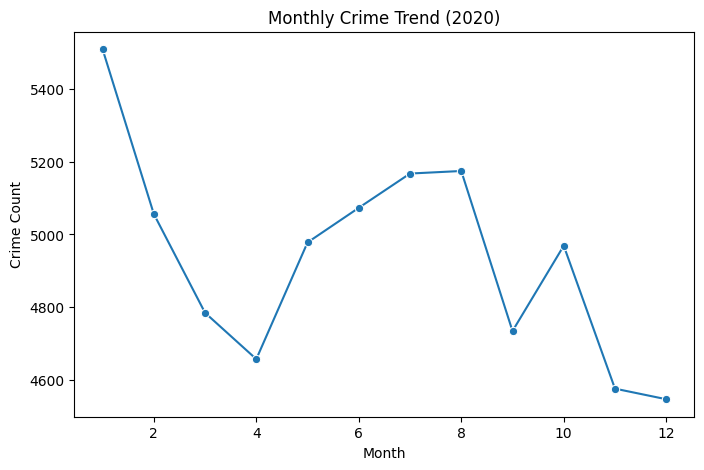

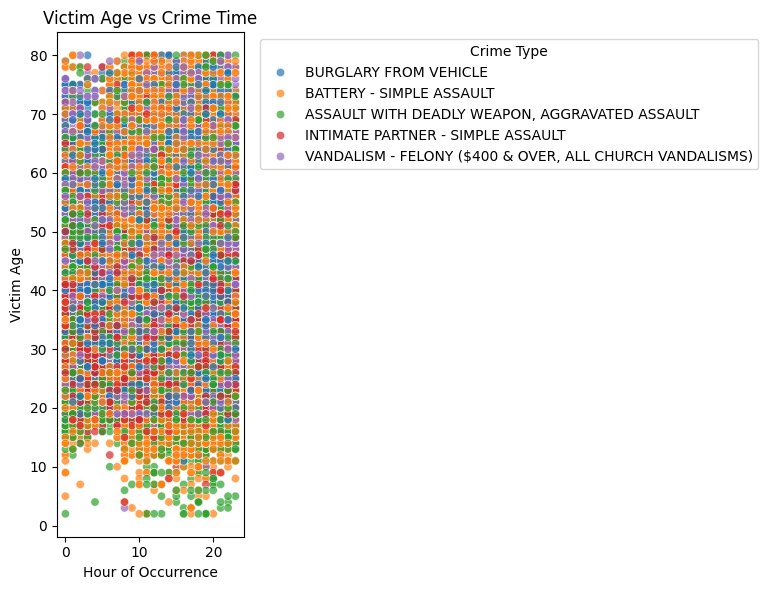

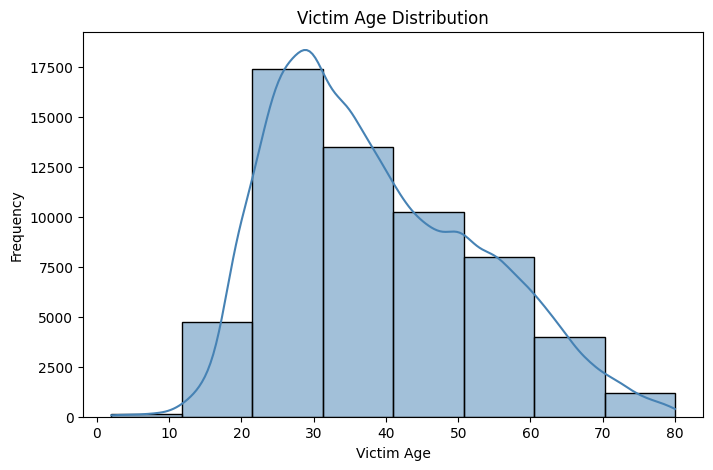

In [ ]:
#Task3
filtered_df = df[
    (df['Occ Year'] == 2020) &
    (df['Vict Age'] > 0) &
    (df['Vict Age'] <= 80)
]
top_crimes = filtered_df['Crm Cd Desc'].value_counts().head(5).index
filtered_df = filtered_df[filtered_df['Crm Cd Desc'].isin(top_crimes)]

import seaborn as sns
#Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(
    y='Crm Cd Desc',
    data=filtered_df,
    palette='viridis'
)
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Type")
plt.title("Top 5 Crime Types (2020)")
plt.tight_layout()
plt.show()

#Line Chart
monthly_df = filtered_df.groupby('Occ Month').size().reset_index(name='Count')
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=monthly_df,
    x='Occ Month',
    y='Count',
    marker='o'
)
plt.xlabel("Month")
plt.ylabel("Crime Count")
plt.title("Monthly Crime Trend (2020)")
plt.show()

#Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=filtered_df,
    x='Occ Hour',
    y='Vict Age',
    hue='Crm Cd Desc',
    palette='tab10',
    alpha=0.7
)
plt.xlabel("Hour of Occurrence")
plt.ylabel("Victim Age")
plt.title("Victim Age vs Crime Time")
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

#Distribution Plot
plt.figure(figsize=(8, 5))
sns.histplot(
    filtered_df['Vict Age'],
    bins=8,
    kde=True,
    color='steelblue'
)
plt.xlabel("Victim Age")
plt.ylabel("Frequency")
plt.title("Victim Age Distribution")
plt.show()


In [ ]:
end_time = time.time()
print("Matplotlib rendering time:", end_time - start_time, "seconds")

Matplotlib rendering time: 104.06750392913818 seconds
